## (0) Settings and Functions

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    StratifiedKFold, RepeatedStratifiedKFold, cross_validate, learning_curve, train_test_split
)
from sklearn.multiclass import OneVsRestClassifier
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import LabelEncoder

from sklearn.feature_extraction.text import CountVectorizer

from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier, PassiveAggressiveClassifier
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.pipeline import Pipeline
from sklearn.base import clone

In [23]:
df = pd.read_csv("../../data/treated/tweet_emotions_ptbr_treated.csv")

df['CLEAN_TEXT'] = (
    df['CLEAN_TEXT']
    .fillna("")        # remove NaN
    .astype(str)       # garante string
)

print(df.shape)
df.head(3)

(12420, 3)


,UNCLEAN_TEXT,EMOTION,CLEAN_TEXT
0,͏ ͏ ͏ ͏ ͏ ͏ ͏ ͏\nque júbilo incalculável ver t...,alegria,jubil incalculavel ver tod quer prest ano pass...
1,". 𝘀𝗮𝗽𝗼𝗻𝘁𝗮𝗺𝗲𝗻𝘁𝗼𝗶\nSenhor, arranca do meu coraçã...",decepção,sapontamento senhor arranc coraca qualqu tip d...
2,"A franquia continua ativa, com o desenvolvimen...",decepção,franqu continu ativ desenvolv segund jog embor...


In [24]:
def avaliar_cv(model, X_train, y_train, n_splits=5, n_repeats=6):
    rskf = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=42)

    # macro: trata todas as classes igualmente (classes raras importam tanto quanto classes frequentes)
    # weighted: melhor se houver desbalanceamento (penaliza menos erros em classes raras)
    scoring = {
        'accuracy': 'accuracy',
        'f1_macro': 'f1_macro',
        'precision_macro': 'precision_macro',
        'recall_macro': 'recall_macro'
    }

    results = cross_validate(
        model,
        X_train,
        y_train,
        cv=rskf,
        scoring=scoring,
        n_jobs=-1
    )

    accuracy_scores = results['test_accuracy']
    precision_scores = results['test_precision_macro']
    recall_scores  = results['test_recall_macro']
    f1_scores = results['test_f1_macro']

    return {
        "Accuracy":  (accuracy_scores.mean(),  accuracy_scores.std(),  accuracy_scores),
        "Precision_macro": (precision_scores.mean(), precision_scores.std(), precision_scores),
        "Recall_macro":  (recall_scores.mean(),  recall_scores.std(),  recall_scores),
        "F1_macro":   (f1_scores.mean(),   f1_scores.std(),   f1_scores),
    }

def plotar_learning_curve(model, X_train, y_train, model_name, cv=5, scoring='f1_macro'):
    train_sizes, train_scores, valid_scores = learning_curve(
        model,
        X_train,
        y_train,
        cv=StratifiedKFold(n_splits=cv, shuffle=True, random_state=42),
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring=scoring
    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    valid_mean = valid_scores.mean(axis=1)
    valid_std = valid_scores.std(axis=1)

    plt.figure(figsize=(8,6))
    plt.plot(train_sizes, train_mean, 'o-', color="blue", label="Training Score")
    plt.plot(train_sizes, valid_mean, 'o-', color="orange", label="Validation Score")

    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="blue")
    plt.fill_between(train_sizes, valid_mean - valid_std, valid_mean + valid_std, alpha=0.1, color="orange")

    plt.title(f"Learning Curve - {model_name}")
    plt.xlabel("Training Set Size")
    plt.ylabel(scoring)
    plt.ylim(0, 1.05)
    plt.grid(True)
    plt.legend()
    plt.show()

def plot_feature_importance_top_k(model, feature_names, k=15, model_name="Model"):
    clf = model[-1] if hasattr(model, "__getitem__") else model

    if not hasattr(model, "feature_importances_"):
        raise ValueError("The model does not have feature_importances_.") 
    
    importances = clf.feature_importances_
    idx_sorted = np.argsort(importances)[::-1][:k]
    
    # Plot 
    plt.figure(figsize=(10, 6)) 
    plt.barh(range(k), importances[idx_sorted][::-1]) 
    plt.yticks(range(k), np.array(feature_names)[idx_sorted][::-1])
    plt.title(f"Top-{k} Feature Importances - {model_name}")
    plt.xlabel("Importance") 
    plt.tight_layout() 
    plt.show()

def plot_permutation_importance_top_k(model, X_val, y_val, feature_names, k=15, model_name="Model", scoring="f1_macro"):
    result = permutation_importance(
        model, X_val, y_val,
        n_repeats=10,
        scoring=scoring,
        random_state=42
    )

    importances = result.importances_mean
    idx_sorted = np.argsort(importances)[::-1][:k]

    plt.figure(figsize=(10, 6))
    plt.barh(range(k), importances[idx_sorted][::-1])
    plt.yticks(range(k), np.array(feature_names)[idx_sorted][::-1])
    plt.title(f"Top-{k} Permutation Importance - {model_name}")
    plt.xlabel(f"Impact on {scoring}")
    plt.tight_layout()
    plt.show()

## (1) Predict Baseline

In [25]:
X_text = df['CLEAN_TEXT']

le = LabelEncoder()
y = le.fit_transform(df['EMOTION'])

X_text_train, X_text_aux, y_train, y_aux = train_test_split(
    X_text, y,
    train_size=0.70,
    random_state=42,
    stratify=y
)

X_text_dev, X_text_test, y_dev, y_test = train_test_split(
    X_text_aux, y_aux,
    train_size=0.50,
    random_state=42,
    stratify=y_aux
)


Running model: LogisticRegression


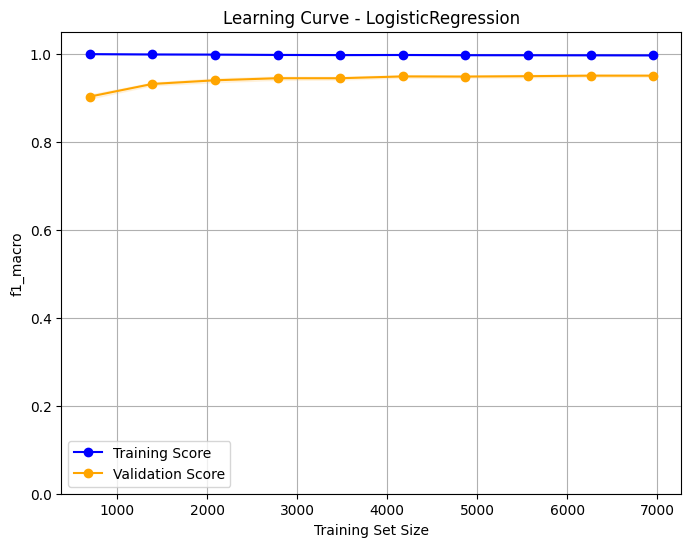


Running model: RidgeClassifier


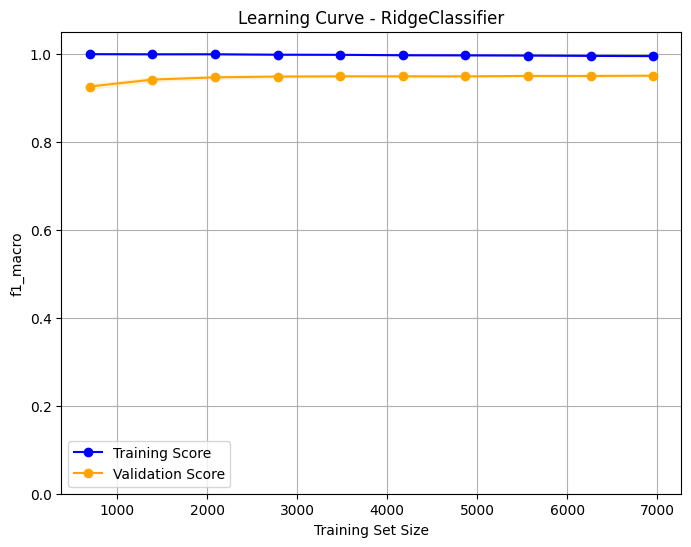


Running model: SGDClassifier


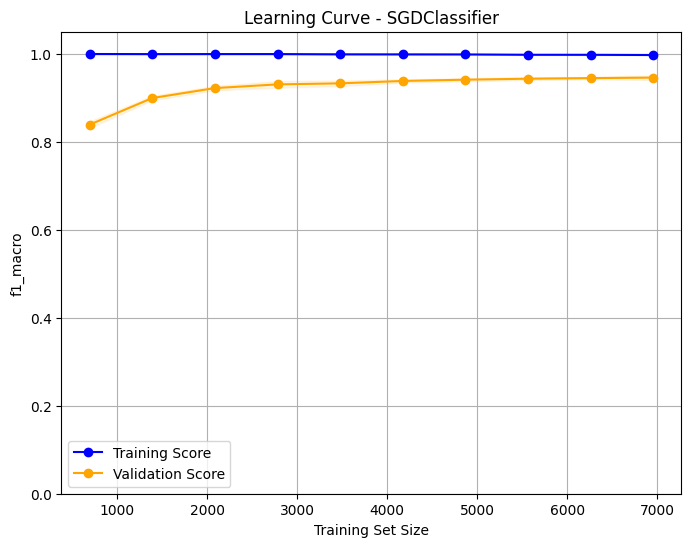


Running model: PassiveAggressive


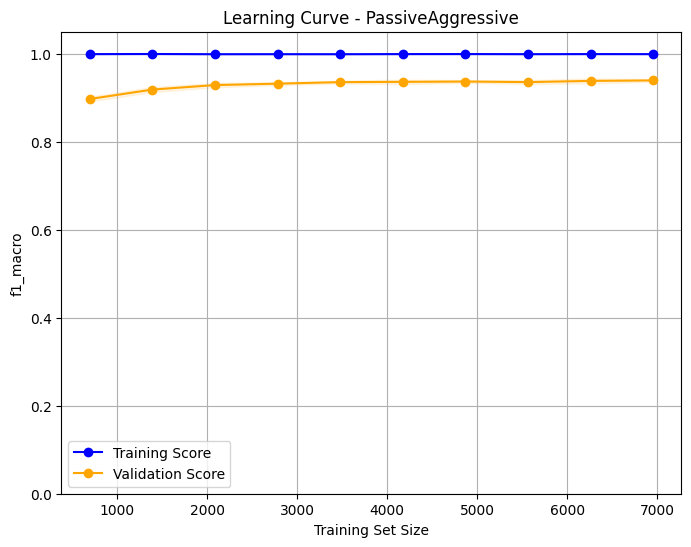


Running model: MultinomialNB


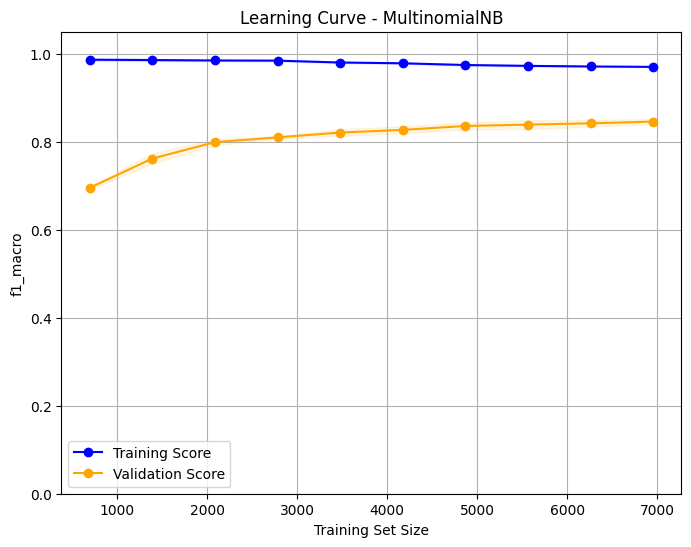


Running model: ComplementNB


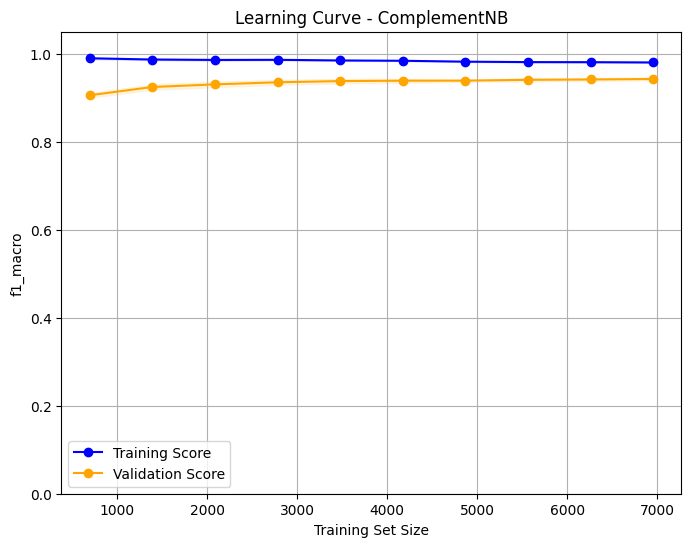


Running model: KNN


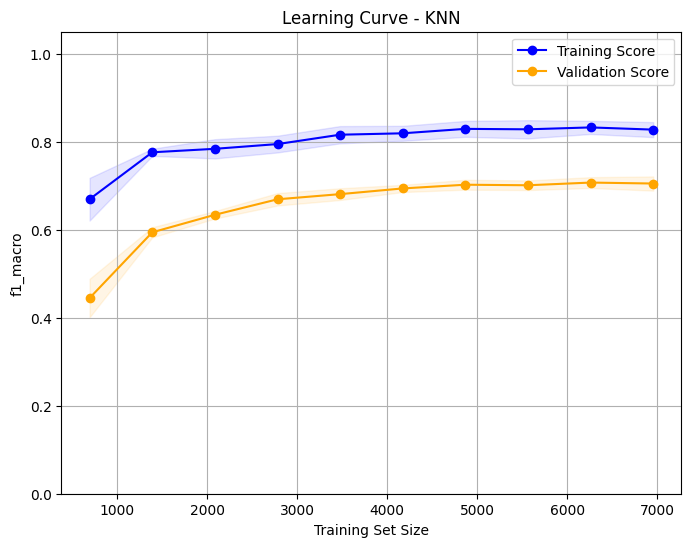


Running model: DecisionTree


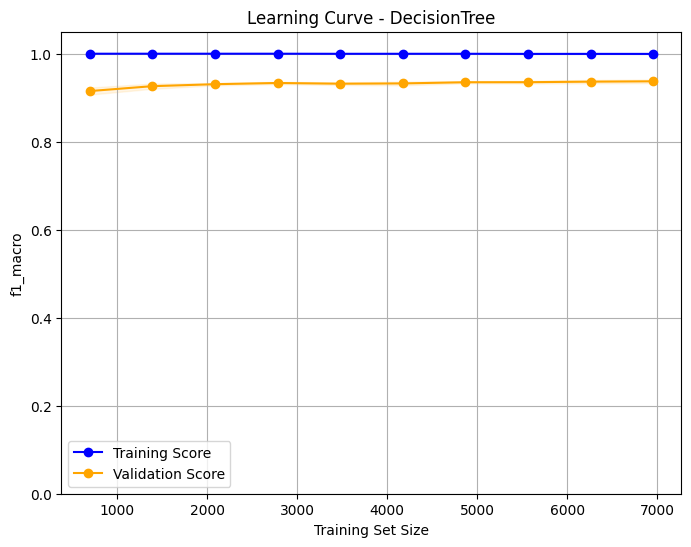


Running model: LinearSVC


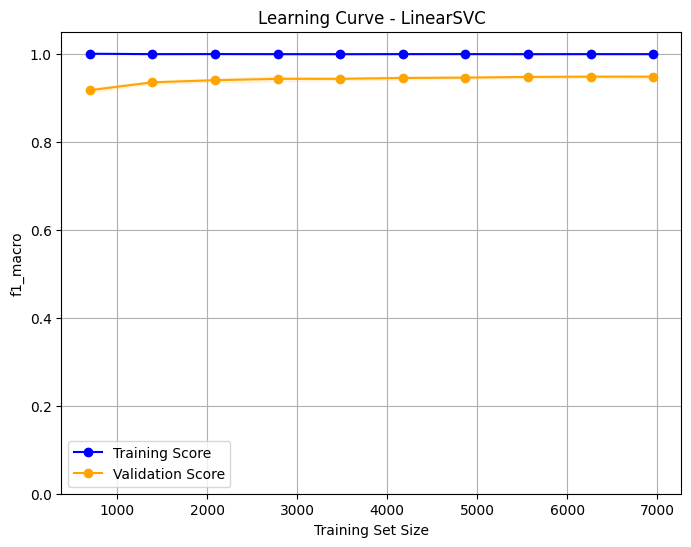


Running model: SVC


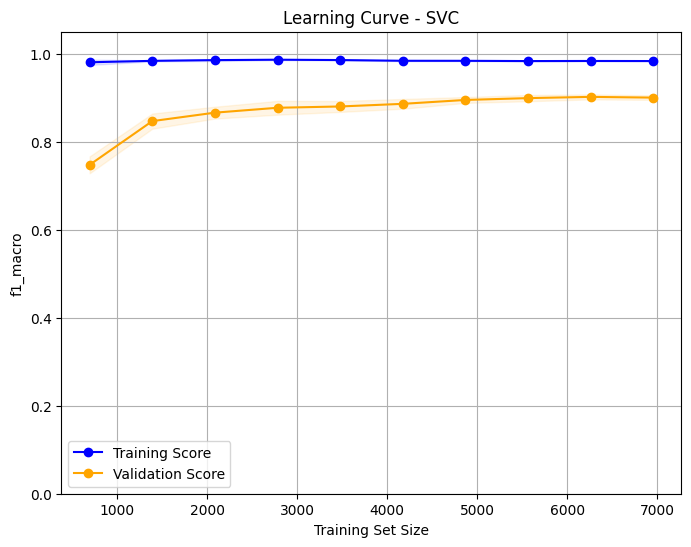


Running model: RandomForest


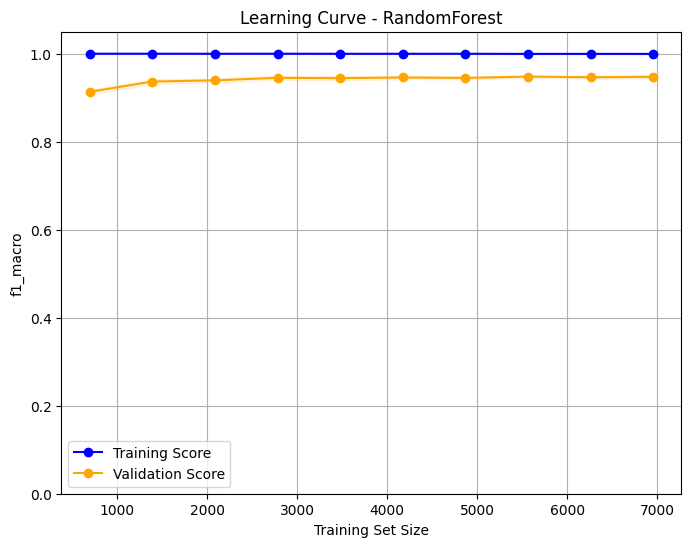


Running model: XGBClassifier


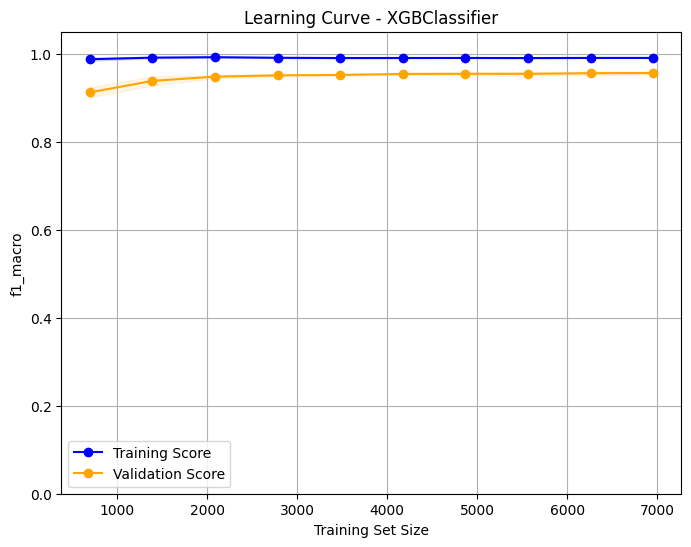

Best model: XGBClassifier


In [26]:
models_for_testing = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
    "RidgeClassifier": RidgeClassifier(random_state=42),
    "SGDClassifier": OneVsRestClassifier(SGDClassifier(random_state=42)),
    "PassiveAggressive": OneVsRestClassifier(PassiveAggressiveClassifier(random_state=42)),
    "MultinomialNB": MultinomialNB(),
    "ComplementNB": ComplementNB(),
    "KNN": KNeighborsClassifier(),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "LinearSVC": OneVsRestClassifier(LinearSVC(random_state=42)),
    "SVC": SVC(random_state=42),
    "RandomForest": RandomForestClassifier(random_state=42),
    "XGBClassifier": XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42,
        verbosity=0
    )
}

results = []

def run_predictions(name, model, X_text_train, y_train):
    print("\n" + "=" * 80)
    print(f"Running model: {name}")
    print("=" * 80)

    pipe = Pipeline([
        ("bow", CountVectorizer()),
        ("model", model)
    ])

    cv_res = avaliar_cv(clone(pipe), X_text_train, y_train, n_splits=5, n_repeats=6)

    plotar_learning_curve(clone(pipe), X_text_train, y_train, model_name=name, cv=5, scoring="f1_macro")

    results.append({
        "Model": name,

        "CV_Accuracy_mean":  cv_res["Accuracy"][0],
        "CV_Accuracy_std":   cv_res["Accuracy"][1],
        "CV_Accuracy_all":   cv_res["Accuracy"][2],

        "CV_Precision_macro_mean":  cv_res["Precision_macro"][0],
        "CV_Precision_macro_std":   cv_res["Precision_macro"][1],
        "CV_Precision_macro_all":   cv_res["Precision_macro"][2],

        "CV_Recall_macro_mean":  cv_res["Recall_macro"][0],
        "CV_Recall_macro_std":   cv_res["Recall_macro"][1],
        "CV_Recall_macro_all":   cv_res["Recall_macro"][2],

        "CV_F1_macro_mean":  cv_res["F1_macro"][0],
        "CV_F1_macro_std":   cv_res["F1_macro"][1],
        "CV_F1_macro_all":   cv_res["F1_macro"][2],
    })

for name, model in models_for_testing.items():
    run_predictions(name, model, X_text_train, y_train)

df_results = pd.DataFrame(results)
best_model = df_results.sort_values(by="CV_F1_macro_mean", ascending=False).iloc[0]["Model"]
print("Best model:", best_model)

In [30]:
def format_results(df):
    formatted_df = df.copy()

    for metric in ["Accuracy", "Precision_macro", "Recall_macro", "F1_macro"]:
        mean_col = f"CV_{metric}_mean"
        std_col = f"CV_{metric}_std"

        formatted_df[metric] = (
            formatted_df[mean_col].round(4).astype(str)
            + " ± "
            + formatted_df[std_col].round(4).astype(str)
        )

        # Remove as colunas originais
        formatted_df = formatted_df.drop(columns=[mean_col, std_col])

    # reorganiza colunas
    cols = ["Model", "Accuracy", "Precision_macro", "Recall_macro", "F1_macro"]
    return formatted_df[cols]

df_results.to_csv("../../data/out/baseline/baseline_03_TweetEmotionsPTBR_BoW.csv")
formatted_df = format_results(df_results)
formatted_df.style.hide(axis="index")

Model,Accuracy,Precision_macro,Recall_macro,F1_macro
LogisticRegression,0.95 ± 0.004,0.9537 ± 0.0036,0.9504 ± 0.004,0.9513 ± 0.0039
RidgeClassifier,0.9481 ± 0.0039,0.9541 ± 0.0033,0.9487 ± 0.004,0.9499 ± 0.0037
SGDClassifier,0.9459 ± 0.0039,0.9495 ± 0.0034,0.9463 ± 0.004,0.9471 ± 0.0037
PassiveAggressive,0.9406 ± 0.0049,0.9424 ± 0.0046,0.9412 ± 0.005,0.9414 ± 0.0048
MultinomialNB,0.8472 ± 0.0081,0.8638 ± 0.0071,0.8474 ± 0.0082,0.8498 ± 0.008
ComplementNB,0.9422 ± 0.0045,0.943 ± 0.0044,0.9428 ± 0.0046,0.9424 ± 0.0045
KNN,0.7036 ± 0.0154,0.763 ± 0.0092,0.7069 ± 0.015,0.7063 ± 0.0149
DecisionTree,0.9374 ± 0.0043,0.9398 ± 0.004,0.9382 ± 0.0042,0.9381 ± 0.0042
LinearSVC,0.9478 ± 0.0049,0.9499 ± 0.0047,0.9484 ± 0.0049,0.9487 ± 0.0048
SVC,0.8921 ± 0.0067,0.9215 ± 0.0049,0.8922 ± 0.0067,0.9004 ± 0.006


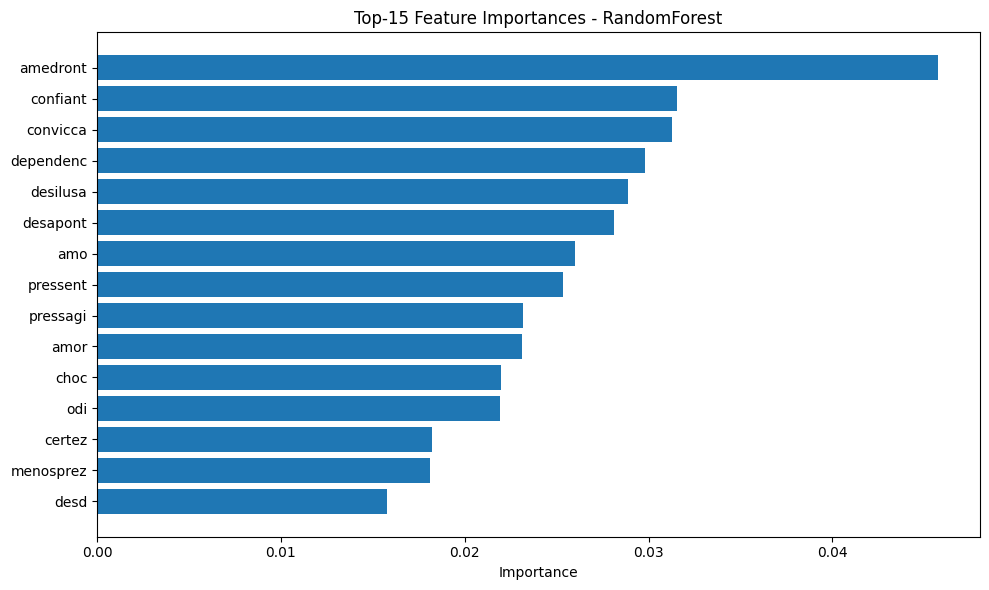

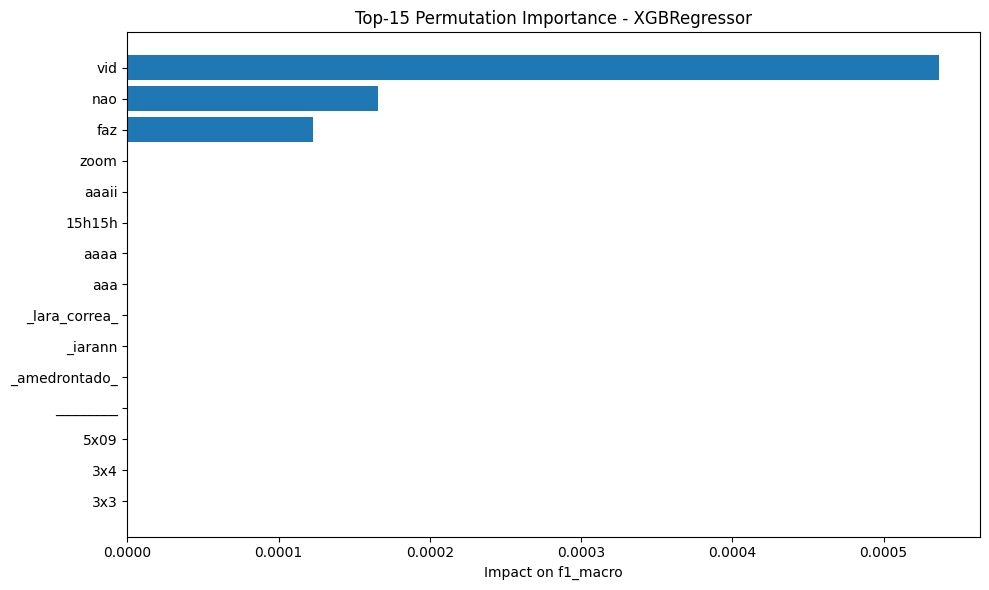

In [31]:
pipe_rf = Pipeline([
    ("bow", CountVectorizer()),
    ("model", RandomForestClassifier(random_state=42))
])
pipe_rf.fit(X_text_train, y_train)

feature_names = pipe_rf["bow"].get_feature_names_out()
plot_feature_importance_top_k(pipe_rf["model"], feature_names, k=15, model_name="RandomForest")

pipe_xgb = Pipeline([
    ("bow", CountVectorizer()),
    ("model", XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42,
        verbosity=0
    ))
])

pipe_xgb.fit(X_text_train, y_train)
vectorizer = pipe_xgb.named_steps["bow"]
regressor = pipe_xgb.named_steps["model"]

X_dev_transformed = vectorizer.transform(X_text_dev).toarray()

feature_names = vectorizer.get_feature_names_out()

plot_permutation_importance_top_k(
    regressor,
    X_dev_transformed,
    y_dev,
    feature_names,
    k=15,
    model_name="XGBRegressor",
    scoring="f1_macro"
)